##### Imports and setup

In [2]:
# setup the notebook environment
!pixi install
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import logging
logging.getLogger("pypsa.network.descriptors").setLevel(logging.ERROR)

def ensure_project_root_on_path(marker_dir: str = "modules") -> str:
    """Find the nearest ancestor folder containing `marker_dir`, add it to
    sys.path (front) and return its path. Raises RuntimeError if not found.
    """
    cwd = Path.cwd().resolve()
    # If cwd contains marker_dir, use cwd
    if (cwd / marker_dir).exists():
        p = str(cwd)
        if p not in sys.path:
            sys.path.insert(0, p)
        return p
    # Walk parents
    for parent in cwd.parents:
        if (parent / marker_dir).exists():
            p = str(parent)
            if p not in sys.path:
                sys.path.insert(0, p)
            return p
    raise RuntimeError(f"Could not find '{marker_dir}' directory in {cwd} or any parent")


project_root = ensure_project_root_on_path()
print("Added project root to sys.path:", project_root)

# imports and loading data
from modules.analysis_toolkit.analyzer import ResultsComputer, GeoOptions
from modules.analysis_toolkit.helpers.plotting import TimeSeriesPlot, HistogramPlot, BarChartPlot, WaterfallPlot
import pandas as pd

study_years = [2030, 2040]
rc = {year: ResultsComputer(year=year) for year in study_years}

✔ The default environment has been installed.
Added project root to sys.path: /Users/rca/PycharmProjects/NGV-FBMC


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.6)
INFO:pypsa.network.io:Imported network 'Status Quo (SQ) - 2030' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.6)
INFO:pypsa.network.io:Imported network 'Integrated Energy Market (IEM) - 2030' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.6)
INFO:pypsa.network.io:Imported network 'Flow-based market coupling (FBMC) - 2030' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.6)
INFO:pypsa.network.io:Imported network 'SQ (2030) - redispatch' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, sto

# ANALYSIS OF FLOW RESTRICTION AND COMPENSATION

## comparison of dispatch flows through the interconnectors for the different scenarios (sq, iem, iem_fb)

Calling method interconnector_flows
['#00ACC2', '#F4A74F', '#8CBB13']


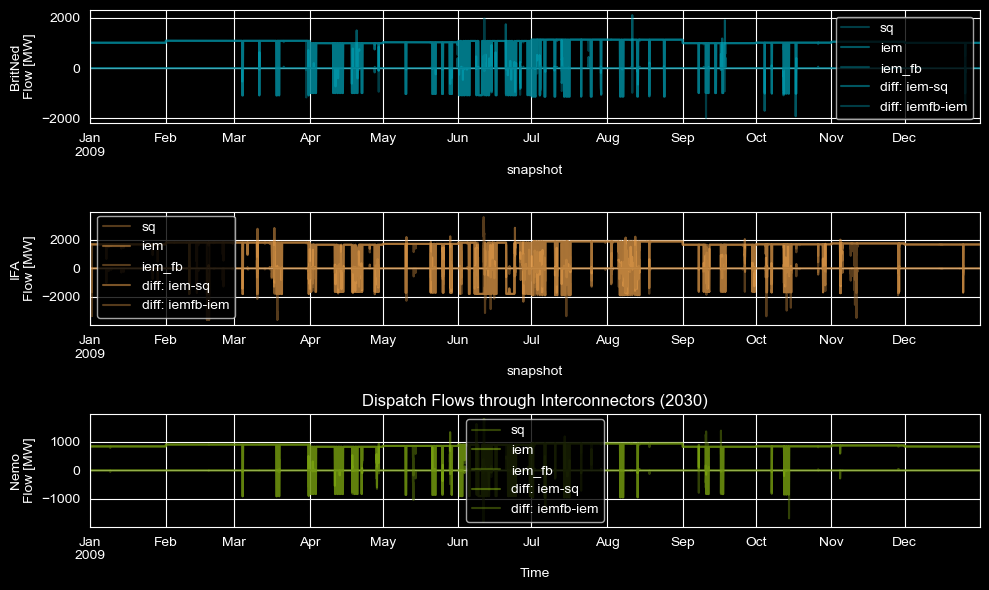

In [3]:
# rc[2030].interconnector_flows.compare_dispatch()
TimeSeriesPlot.interconnector_flows(rc[2030], interconnectors=["BritNed", "IFA", "Nemo"])

Calling method: restricted_capacity
Calling method interconnector_flows
Calling method interconnector_flows


/Users/rca/PycharmProjects/NGV-FBMC/modules/analysis_toolkit/helpers/plotting.py:12: UserWarning:

Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.



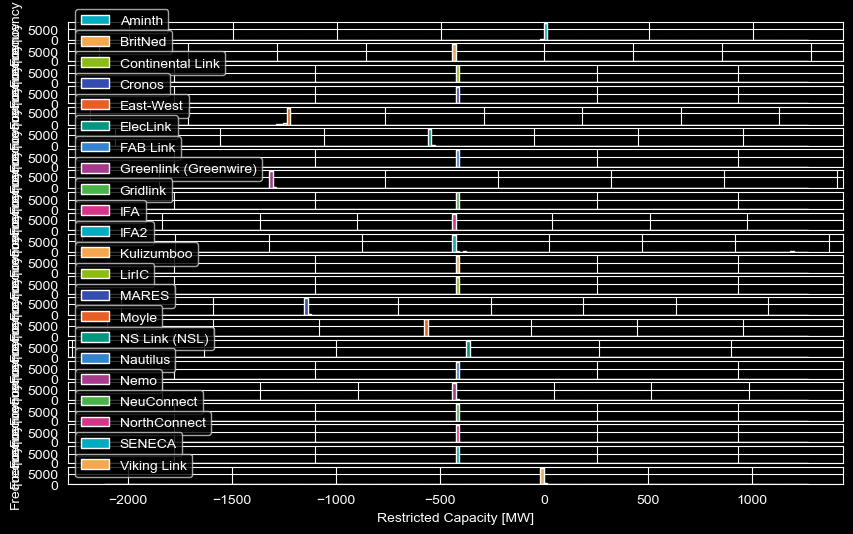

In [5]:
# rc[2030].restricted_capacity()
HistogramPlot.restricted_capacity(rc[2030])

In [2]:
# now import project code
from modules.analysis_toolkit.analyzer import ResultsComputer
from modules.analysis_toolkit.helpers.plotting import TimeSeriesPlot, HistogramPlot, BarChartPlot, WaterfallPlot

study_years = [2030] # [2030, 2040]
rc = {year: ResultsComputer(year=year) for year in study_years}

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.6)
INFO:pypsa.network.io:Imported network 'Status Quo (SQ) - 2030' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.6)
INFO:pypsa.network.io:Imported network 'Integrated Energy Market (IEM) - 2030' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.6)
INFO:pypsa.network.io:Imported network 'Integrated Energy Market (IEM) - 2030' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.6)
INFO:pypsa.network.io:Imported network 'SQ (2030) - redispatch' has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storag

# ANALYSIS OF FLOW RESTRICTION AND COMPENSATION

## comparison of dispatch flows through the interconnectors for the different scenarios (sq, iem, iem_fb)

['#00ACC2', '#F4A74F', '#8CBB13']


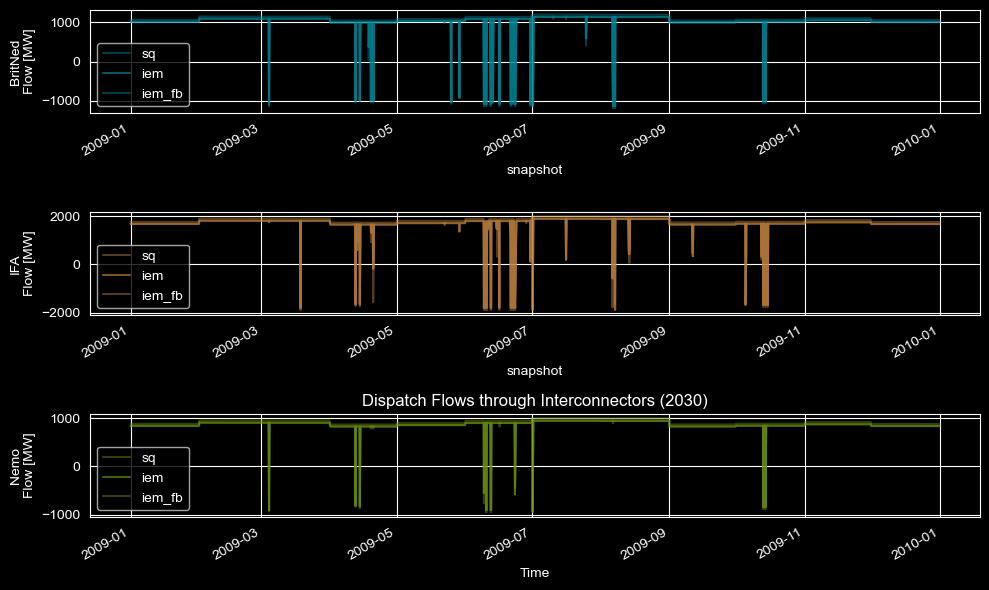

In [34]:
# rc[2030].interconnector_flows.compare_dispatch()
TimeSeriesPlot.interconnector_flows(rc[2030], interconnectors=["BritNed", "IFA", "Nemo"])

/Users/rca/PycharmProjects/NGV-FBMC/modules/analysis_toolkit/helpers/plotting.py:12: UserWarning:

Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.



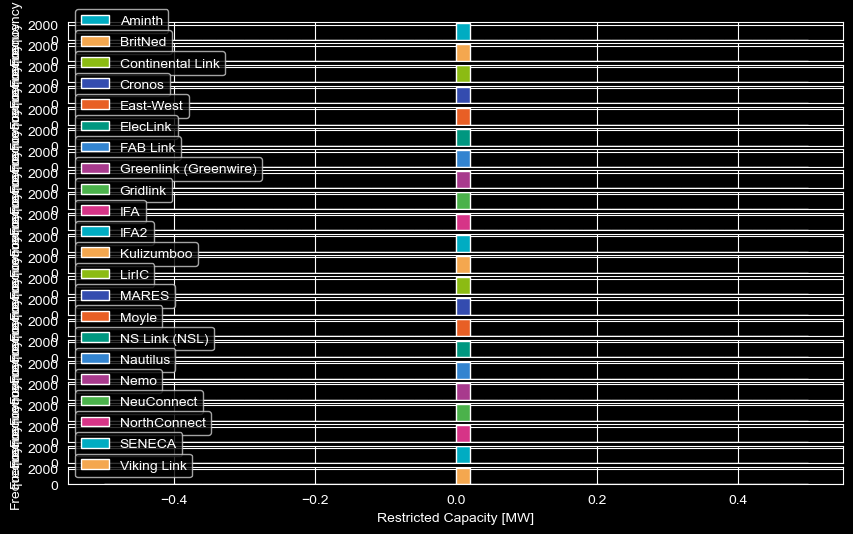

In [13]:
# rc[2030].restricted_capacity()
HistogramPlot.restricted_capacity(rc[2030])